In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

try:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",
    })
except Exception as e:
    print(f"Could not enable LaTeX rendering: {e}\nFalling back to default.")

In [75]:
data = []

for xi in np.arange(0.05, 0.51, 0.05):
    for eta in np.arange(0.05, 0.51, 0.05):
        data.append(pd.read_parquet(f"C:\\Users\\rossi\\Documents\\tesi\\apdl\\grid\\grid_{xi:.3f}_{eta:.3f}.parquet"))
        

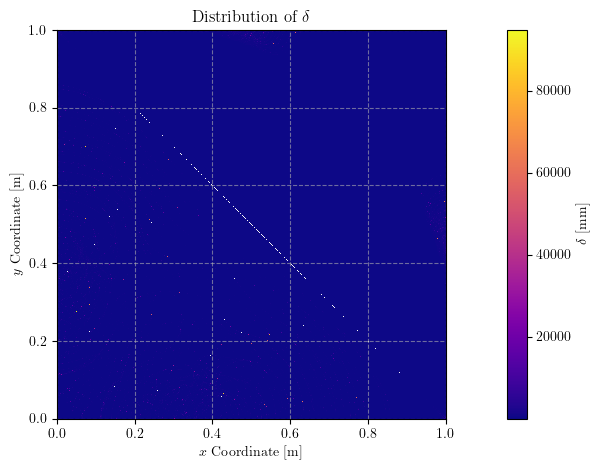

In [83]:
fig, ax = plt.subplots()

delta_thr = 1e-5

# Ensure total is initialized as a float array of the correct length
# Using .values ensures we are working with a clean NumPy array
total = np.zeros(len(data[0]), dtype=float)

for i in range(len(data)):
    # Calculate the denominator for the entire grid
    denom = np.abs(data[i]['EPS_ETA'].values + data[i]['EPS_XI'].values)
    
    # Create a mask for values where division is safe
    mask = denom > 1e-18  # Using a very small epsilon instead of 0 for stability
    
    # Update only the indices where the mask is True
    # This prevents the "ValueError: operands could not be broadcast together"
    total[mask] += delta_thr / denom[mask]

# Prepare data for pivoting
# It's important to use .values or ensure indices align if 'data' contains DataFrames
diff_df = pd.DataFrame({
    'X': data[0]['X'].values,
    'Y': data[0]['Y'].values,
    'total': total / len(data),
})

# Pivot the data to create a 2D grid for plotting
diff_pivot = diff_df.pivot(index='Y', columns='X', values='total')

x_coords = diff_pivot.columns.to_numpy()
y_coords = diff_pivot.index.to_numpy()
C = diff_pivot.to_numpy()

# Apply the threshold for display and convert to mm
display_threshold = 100
# Multiplication on a MaskedArray correctly scales the unmasked data
C_masked = np.ma.masked_greater(C, display_threshold) * 1e3

# Setup colormap
cmap = plt.get_cmap("plasma").copy()
cmap.set_bad(color='whitesmoke') 

# Generate the meshgrid for pcolormesh
X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

# Plot using pcolormesh
# rasterized=True is excellent for large grids to keep the PDF/SVG file sizes small
colormesh = ax.pcolormesh(X_mesh, Y_mesh, C_masked, cmap=cmap, shading='auto', rasterized=True)

# Add colorbar
cbar = fig.colorbar(colormesh, ax=ax, label=r"$\delta$ [mm]")

# Axis formatting
ax.set_xlabel(r"$x$ Coordinate [m]")
ax.set_ylabel(r"$y$ Coordinate [m]")
ax.set_title(r"Distribution of $\delta$")
ax.axis("scaled") # Ensures 1:1 aspect ratio for the physical grid
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [77]:

print("Media totale:")
print(np.average(diff_df['total']))

print("Media singola:")
for i in range(len(data)):
  print(np.mean(delta_thr / np.abs(data[i]['EPS_ETA'] + data[i]['EPS_XI'])))
  

Media totale:
0.051684732005392274
Media singola:
0.17572691971375437
0.12002180884589068
0.09543139601228089
0.07874247508371503
0.06925502486155298
0.06719447274570532
0.06788688219728768
0.06839860642966301
0.06109706703701432
0.07073106864706563
0.1200218088458192
0.09821686133370072
0.08298184941474614
0.07571389067829919
0.08864522401244118
0.0747262648638038
0.08386415219733873
0.08978671712711998
0.08257386679007743
0.09126297943369799
0.09543139601257708
0.08298184941479805
0.08392309657003175
0.09183985895167024
0.09070594977419291
0.09727472076212292
0.09912226208042606
0.10603930264534414
0.16970495767867227
0.24511983697678638
0.07874247508370745
0.0757138906781688
0.09183985895265007
0.17094554018826402
0.14527261206967762
0.1323885001751423
0.1439186520963893
0.16978530869010983
0.19983497127140837
0.23066263139093085
0.06925502486157147
0.08864522401263716
0.0907059497761395
0.1452726120719788
0.15448197370521707
0.30570780663589914
0.31704289034616856
0.392223811330524

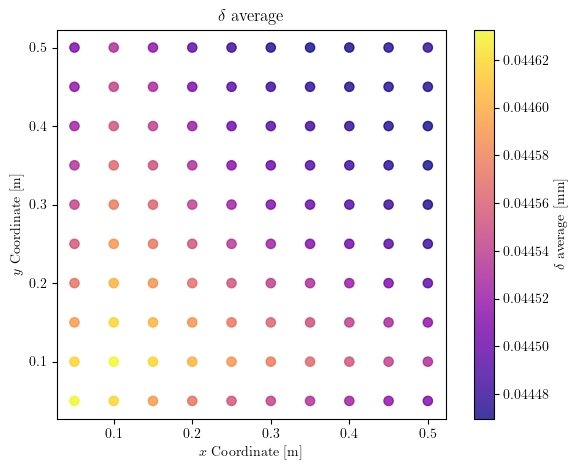

In [ ]:
from numpy import size


fig, ax = plt.subplots()

# np.zeros is safer than np.ndarray as it prevents uninitialized memory artifacts
minimum = np.zeros(len(data)) 

X, Y = np.meshgrid(np.arange(0.05, 0.51, 0.05), np.arange(0.05, 0.51, 0.05))

for i in range(len(data)):
    # Calculate the denominator for the entire grid
    denom = np.abs(data[i]['EPS_ETA'].values + data[i]['EPS_XI'].values)
    
    # Create a mask for values where division is safe
    mask = denom > 1e-18  # Using a very small epsilon instead of 0 for stability
    
    # Update only the indices where the mask is True
    # This prevents the "ValueError: operands could not be broadcast together"
    minimum[i] = np.min(delta_thr / denom[mask])

# 1. Flatten X and Y so they match the 1D 'minimum' array
x_flat = X.flatten()
y_flat = Y.flatten()

# 2. Define a scaling factor so the dots are clearly visible
# (You may need to adjust this number up or down depending on your actual minimum values)
scaling_factor = 1e6
sizes = minimum * scaling_factor

# 3. Plot the scatter ON the ax object BEFORE plt.show()
# s=sizes maps the size, c=minimum maps the color to the colormap
scatter = ax.scatter(x_flat, y_flat, c=minimum*1e3, s=sizes, cmap='plasma', alpha=0.8)

# Format the plot
ax.set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_title(r"$\min\delta$")
# ax.axis("scaled") # Ensures the geometry isn't distorted
ax.axis('scaled')
ax.grid(True, linestyle='--', alpha=0.6, which='minor')

# Optional but highly recommended: Add a colorbar
cbar = fig.colorbar(scatter, ax=ax, label=r"$\min\delta$ $\left[\mathrm{mm}\right]$")

# Adjust layout and show the final plot
plt.tight_layout()
plt.show()